The Black Scholes Model:

Assumes the price of the underlying follows a GBM with constant $\mu$ and $\sigma$ -> price european options

BS PDE:
$$\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - rV = 0$$



From solving it we can price our european call:

$$C(S, t) = S N(d_1) - K e^{-r(T-t)} N(d_2)$$



$N(d_1)$ : delta of the option -> first order sensitivity of the option's price wrt to the underlying stock price : Stock move amount A -> option moves delta x A

K $e^{-r(T-t)}$ : discounted strike price

$N(d_2)$ : probability the option finishes in the money




with :

- N being the Normal distribution's CDF

- $$d_1 = \frac{\ln\left(\frac{S}{K}\right) + \left(r + \frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}$$

- $$d_2 = d_1 - \sigma\sqrt{T-t} = \frac{\ln\left(\frac{S}{K}\right) + \left(r - \frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}$$


In [1]:
from deep_hedging.gbm import simulate_gbm
from deep_hedging.engine import pnl 
from deep_hedging.payoffs import call_payoff

import torch
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import interactive

import warnings
warnings.filterwarnings("ignore")

def _gbm(seed = 0):
    g = torch.Generator().manual_seed(seed)
    return g

In [2]:
def test_black_scholes_call(S, K, tau, sigma, r):
    
    safeguard_tau = np.where(tau > 0, tau, np.ones_like(tau))
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * safeguard_tau) / (sigma * np.sqrt(safeguard_tau))
    d2 = d1 - sigma * np.sqrt(safeguard_tau)
    delta = si.norm.cdf(d1)
    
    call_price = (S * delta) - K * np.exp(-r * safeguard_tau) * si.norm.cdf(d2)
    
    return call_price, delta

In [ ]:
def var_plot(K, tau, sigma, r):
    S = torch.linspace(50, 150, 100)
    prices = []
    deltas = []
    for s in S:
        price, delta = test_black_scholes_call(s, K, tau, sigma, r)
        prices.append(price)
        deltas.append(delta)
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(S, prices, color='blue', label='Call Price')
    ax2.plot(S, deltas, color='red', label='Delta')
    
    ax1.set_xlabel('Stock Price (S)')
    ax1.set_ylabel('Call Price', color='blue')
    ax2.set_ylabel('Delta', color='red')
        
        
    ax1.tick_params(axis='y', labelcolor='blue')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title(f'bs Call Option Price and Delta\nK={K:.2f}, tau={tau:.2f}, sigma={sigma:.2f}, r={r:.2f}')
    plt.show()
    

plot = interactive(var_plot,
                   K=widgets.FloatSlider(value=100, min=50, max=150, step=1, description='K'),
                   tau=widgets.FloatSlider(value=1, min=0.01, max=2, step=0.01, description='tau'),
                   sigma=widgets.FloatSlider(value=0.2, min=0.01, max=1, step=0.01, description='sigma'),
                   r=widgets.FloatSlider(value=0.05, min=-0.1, max=0.1, step=0.01, description='r')
                   )
plot

interactive(children=(FloatSlider(value=100.0, description='K', max=150.0, min=50.0, step=1.0), FloatSlider(va…

In [4]:
def black_scholes_call(S, K, tau, sigma, r):
    
    safeguard_tau = torch.where(tau > 0, tau, torch.ones_like(tau))
    
    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * safeguard_tau) / (sigma * torch.sqrt(safeguard_tau))
    d2 = d1 - sigma * torch.sqrt(safeguard_tau)
    delta = torch.distributions.Normal(0, 1).cdf(d1)
    
    call_price = (S * delta) - K * torch.exp(-r * safeguard_tau) * torch.distributions.Normal(0, 1).cdf(d2)
    
    return call_price, delta

In [5]:
def delta_hedge_simulation(S0, mu, sigma, T, K, r=0.0, n_steps=100, n_paths=1000):
    
    t, S = simulate_gbm(S0, mu, sigma, T, n_steps, n_paths, generator=_gbm())
    
    tau = (T - t).view(1, -1, 1)
    call_price, delta = black_scholes_call(S, K, tau, sigma, r)
    
    payoff = call_payoff(S[:, -1, 0], K)
    
    p0 = call_price[:, 0, 0]
    
    delta_hold = delta[:, :-1, :]
    
    final_pnl = pnl(payoff, S, delta_hold, p0, c=0.0)
    
    return S, final_pnl, delta, t


Option price at t=0: 7.97
Delta at t=0: 0.54
Final P&L of the last price path: 5.50


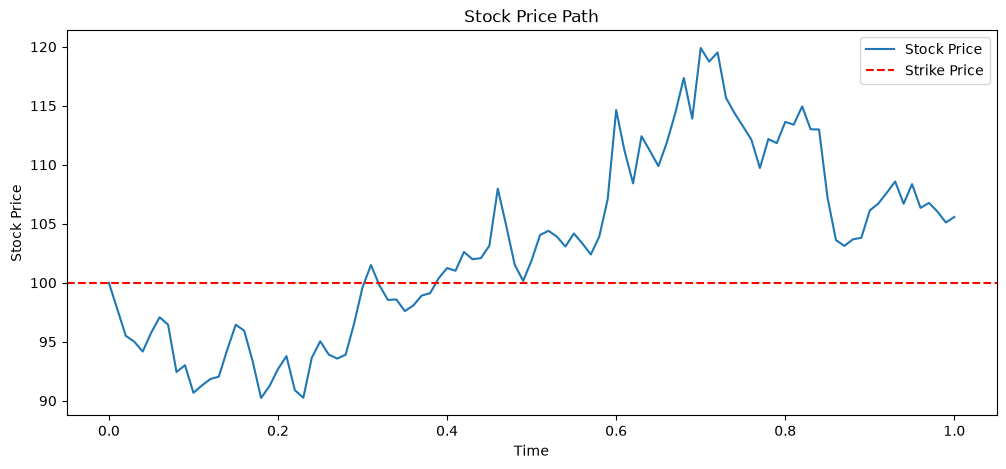

In [ ]:
#test one possible outcome (as an example i took 1 path):

S0 = 100
mu = 0
sigma = 0.2
T = 1
K = 100
r = 0
n_steps = 100
n_paths = 1

p0, delta0 = test_black_scholes_call(S0, K, T, sigma, r)
print(f"Option price at t=0: {p0:.2f}")
print(f"Delta at t=0: {delta0:.2f}")

S, final_pnl, delta, t = delta_hedge_simulation(S0, mu, sigma, T, K, r, n_steps, n_paths)
print(f"Final P&L of the last price path: {final_pnl[0]:.2f}")

plt.figure(figsize=(12, 5))
plt.plot(t, S[-1, :, 0], label="Stock Price")
plt.axhline(K, color='red', linestyle='--', label="Strike Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Stock Price Path")
plt.legend()
plt.show()

Final Mean P&L : -0.27
bs Option Price at t=0: 7.97


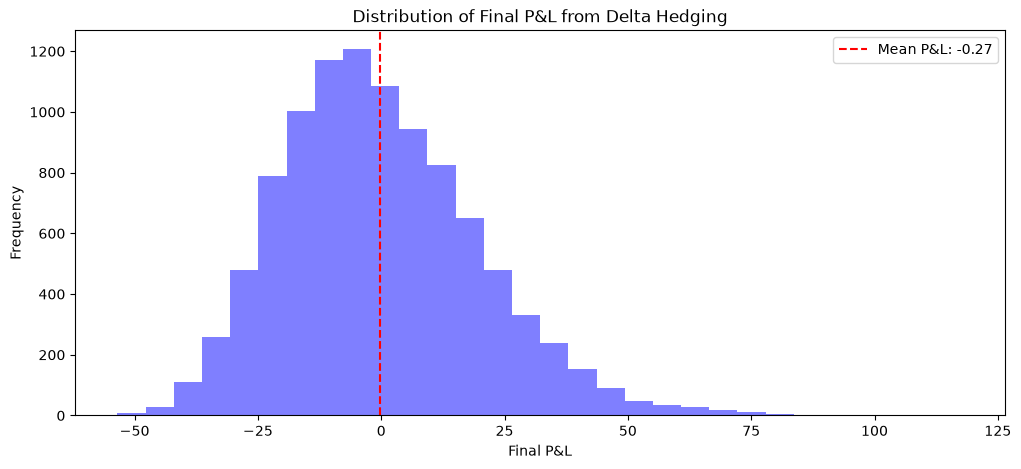

In [7]:
# over multiple paths:

S0 = 100
mu = 0
sigma = 0.2
T = 1
K = 100
r = 0
n_steps = 10_000
n_paths = 10_000


S, final_pnl, delta, t = delta_hedge_simulation(S0, mu, sigma, T, K, r, n_steps, n_paths)
print(f"Final Mean P&L : {final_pnl.mean():.2f}")
print(f"bs Option Price at t=0: {p0:.2f}")

plt.figure(figsize=(12, 5))
plt.hist(final_pnl.numpy(), bins=30, alpha=0.5, color='blue')
plt.axvline(final_pnl.mean().numpy(), color='red', linestyle='--', label=f'Mean P&L: {final_pnl.mean():.2f}')
plt.title("Distribution of Final P&L from Delta Hedging")
plt.xlabel("Final P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()


when n_steps -> $+\infty$

we trade at continuous times, so if trading_costs = 0, our portfolio value converge towards Black Scholes's option premium collected. 

so according to the theory, delta hedging in a continous time should earn us the risk free rate, since we assumed r = 0.0 (following the paper), then as we increase n_paths -> $+\infty$ law of large numbers: P&L -> 0.0

which is exaclty what we see above.